In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [3]:
# Load data
df = pd.read_csv("cleaned_startup(4).csv")

In [4]:
# Convert required columns to numeric (safe)
cols = ['revenue_last_year_usd', 'burn_rate_usd',
        'total_funding_usd', 'initial_funding_usd']

for c in cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna()


In [5]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [6]:
# Create target
df['status'] = (
    (df['revenue_last_year_usd'] > df['burn_rate_usd']) &
    (df['total_funding_usd'] > df['initial_funding_usd'])
).astype(int)

In [7]:
# Features
X = df.drop("status", axis=1)
y = df["status"]

In [11]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [12]:
# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:

# Accuracy
print("Accuracy:", model.score(X_test, y_test))   

Accuracy: 0.9992


🔹 Accuracy: 0.9992
🔹 Precision: 1.0
🔹 Recall: 0.9985141158989599
🔹 F1 Score: 0.9992565055762082
🔹 ROC-AUC: 0.9999974248109167
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       577
           1       1.00      1.00      1.00       673

    accuracy                           1.00      1250
   macro avg       1.00      1.00      1.00      1250
weighted avg       1.00      1.00      1.00      1250

 Confusion Matrix: [[577   0]
 [  1 672]]


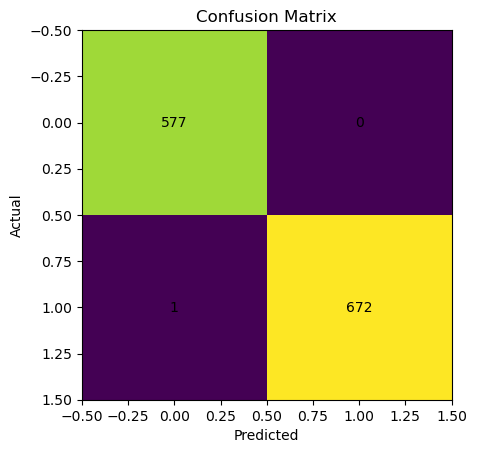

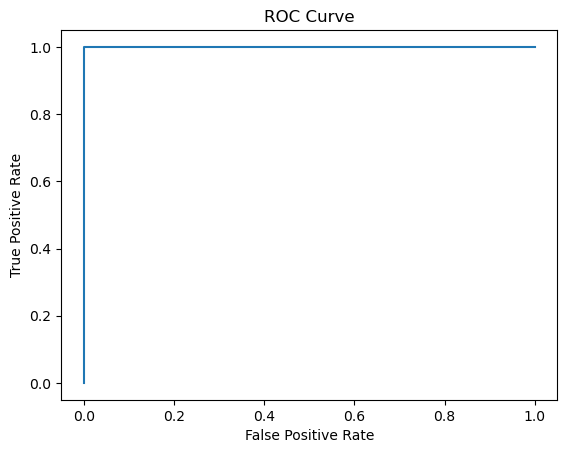

In [14]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

# PREDICTIONS

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]


# BASIC METRICS

print("🔹 Accuracy:", accuracy_score(y_test, y_pred))
print("🔹 Precision:", precision_score(y_test, y_pred))
print("🔹 Recall:", recall_score(y_test, y_pred))
print("🔹 F1 Score:", f1_score(y_test, y_pred))
print("🔹 ROC-AUC:", roc_auc_score(y_test, y_prob))
                                   
# CLASSIFICATION REPORT

print("Classification Report:")
print(classification_report(y_test, y_pred))


# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)
print(" Confusion Matrix:", cm)

# Plot Confusion Matrix
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()


# ROC CURVE

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()